# 📈 Giai đoạn 5: Phân tích Insight Cảm xúc theo Công ty & Trích xuất WordCloud
Trực quan hóa tỷ lệ cảm xúc và từ khóa đặc trưng cho từng doanh nghiệp IT


In [1]:
import re
import sys
sys.path.append("..")
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.utils import generate_wordcloud

# Đọc dữ liệu đã xử lý
df = pd.read_excel("../data/processed/reviews_cleaned.xlsx")
print(f"Tổng số dòng dữ liệu: {len(df)}")
df.head()


Tổng số dòng dữ liệu: 8417


,id,Company Name,Cmt_day,Title,What I liked,Suggestions for improvement,Rating,Salary & benefits,Training & learning,Management cares about me,...,raw_review_text,clean_basic_text,pos_w,neg_w,pos_e,neg_e,total_we,sentiment_ratio,clean_advance_text,sentiment
0,4,Accenture,March 2025,"Môi trường thoải mái, ít áp lực, có thể làm vi...","Môi trường thoải mái, ít áp lực, có thể làm vi...",Cần đánh giá KPI khách quan và phân chia công ...,4,4,4,4,...,"Môi trường thoải mái, ít áp lực, có thể làm vi...",môi trường thoải mái ít áp lực có thể làm việc...,6,3,0,0,9,0.3333,môi_trường thoải_mái áp_lực làm_việc hybrid lư...,Positive
1,4,Accenture,January 2025,Công ty trẻ trung năng động,"Cơ sở vật chất đẹp, công ty trẻ trung năng độn...",Nên nghiên cứu lại range lương của thì trường....,4,3,4,4,...,Công ty trẻ trung năng động . Cơ sở vật chất đ...,công ty trẻ trung năng động cơ sở vật chất đẹp...,5,1,0,0,6,0.6667,công_ty trẻ trung_năng động_cơ_sở_vật_chất đẹp...,Positive
2,4,Accenture,October 2023,Môi trường làm việc thoải mái vui vẻ,"Mội người thân thiện, giúp đỡ lẫn nhau. Chương...",Do công ty làm outsourcing về mảng system nên ...,3,3,3,3,...,Môi trường làm việc thoải mái vui vẻ . Mội ngư...,môi trường làm việc thoải mái vui vẻ mội người...,6,1,0,0,7,0.7143,môi_trường làm_việc thoải_mái vui_vẻ mội thân_...,Neutral
3,4,Accenture,February 2025,good environment for fresher,good env. for fresher to learn and improve the...,Need to forcus more on benefit and evaluate co...,3,2,2,3,...,good environment for fresher . good env. for f...,tốt environment for fresher tốt env for freshe...,4,0,0,0,4,1.0000,tốt environment for fresher tốt env for freshe...,Neutral
4,4,Accenture,February 2023,"Môi trường làm việc thoải mái, vui vẻ","- Văn phòng đẹp, cơ sở vật chất tốt\n- Sếp và ...",- Phát triển văn phòng để rộng rãi hơn\n- Công...,4,3,4,4,...,"Môi trường làm việc thoải mái, vui vẻ . - Văn ...",môi trường làm việc thoải mái vui vẻ văn phòng...,12,1,0,0,13,0.8462,môi_trường làm_việc thoải_mái vui_vẻ văn_phòng...,Positive


## 5.1 Tạo WordCloud toàn bộ tập dữ liệu (Tích cực vs Tiêu cực)


Đã lưu WordCloud tại: ../reports/figures/wordcloud_positive_all.png


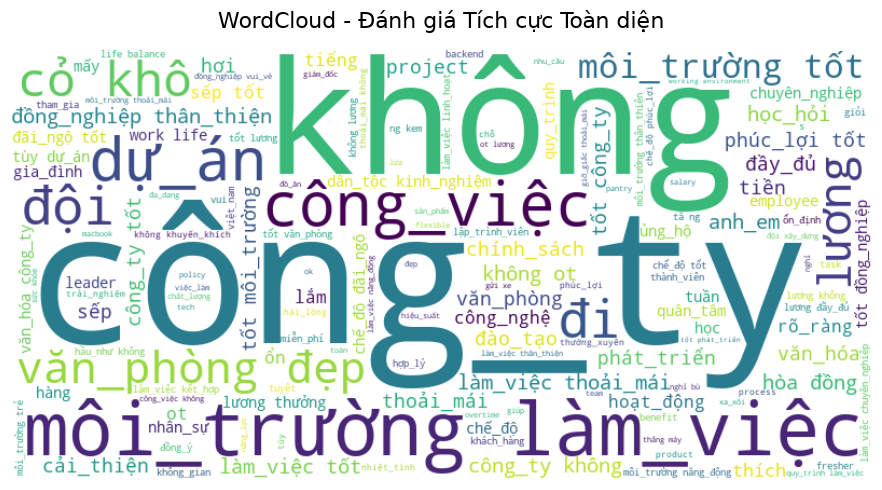

Đã lưu WordCloud tại: ../reports/figures/wordcloud_negative_all.png


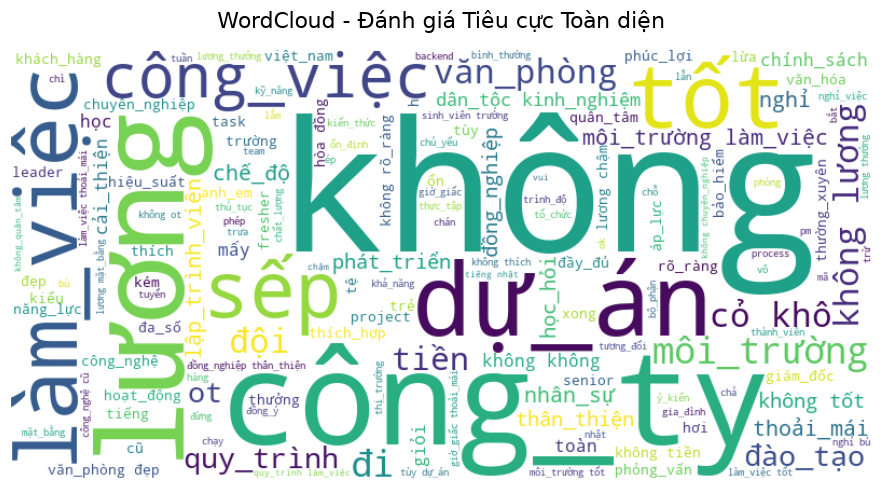

In [2]:
# 1. WordCloud đánh giá Tích cực
pos_text = " ".join(df[df["sentiment"] == "Positive"]["clean_advance_text"].dropna().astype(str))
generate_wordcloud(pos_text, title="WordCloud - Đánh giá Tích cực Toàn diện", save_path="../reports/figures/wordcloud_positive_all.png")

# 2. WordCloud đánh giá Tiêu cực
neg_text = " ".join(df[df["sentiment"] == "Negative"]["clean_advance_text"].dropna().astype(str))
generate_wordcloud(neg_text, title="WordCloud - Đánh giá Tiêu cực Toàn diện", save_path="../reports/figures/wordcloud_negative_all.png")


## 5.2 Phân tích cảm xúc theo từng Công ty cụ thể (Case Study)


Có 34 công ty đạt ngưỡng 50+ review.
Công ty được chọn làm case study: ['FPT Software', 'NashTech']


Đã lưu biểu đồ tại: ../reports/figures/company_fpt_software_sentiment_distribution.png


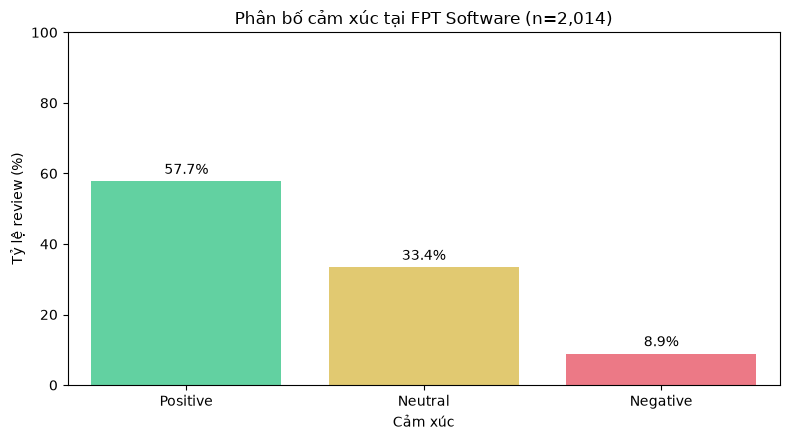

Đã lưu WordCloud tại: ../reports/figures/wordcloud_fpt_software_positive.png


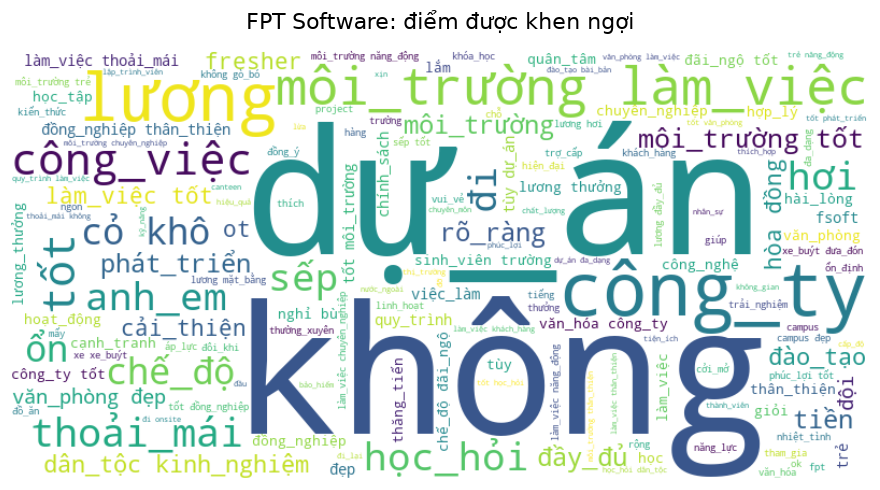

Đã lưu WordCloud tại: ../reports/figures/wordcloud_fpt_software_negative.png


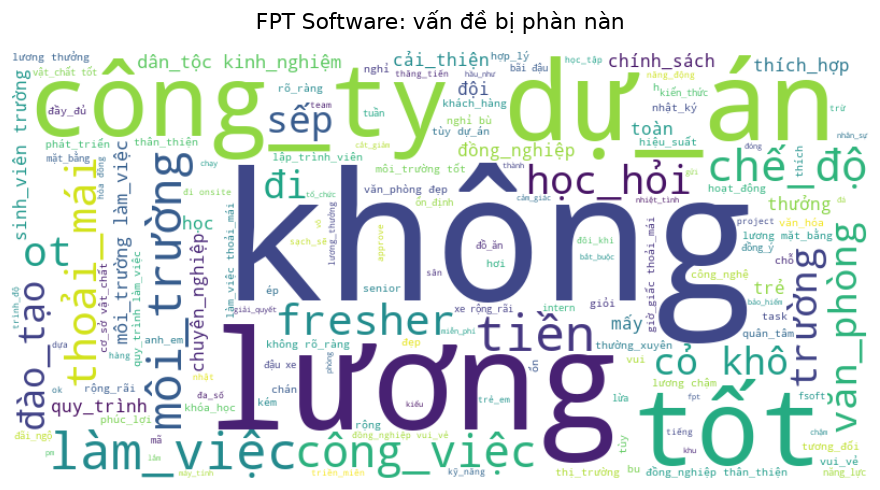

Đã lưu biểu đồ tại: ../reports/figures/company_nashtech_sentiment_distribution.png


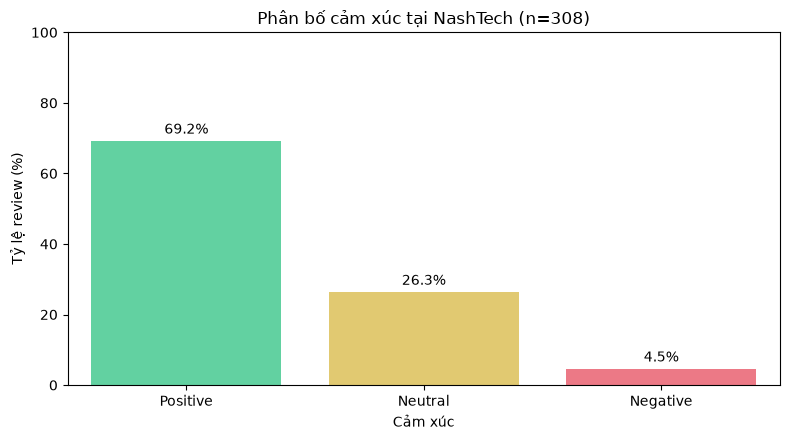

Đã lưu WordCloud tại: ../reports/figures/wordcloud_nashtech_positive.png


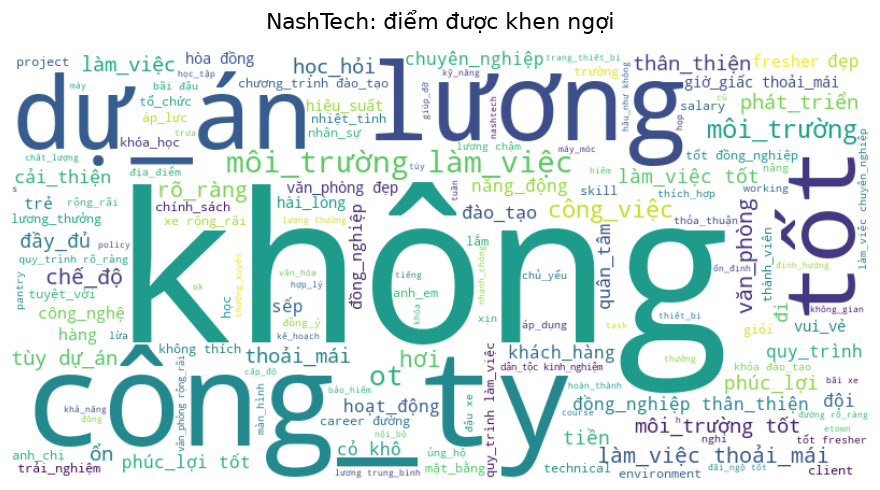

Đã lưu WordCloud tại: ../reports/figures/wordcloud_nashtech_negative.png


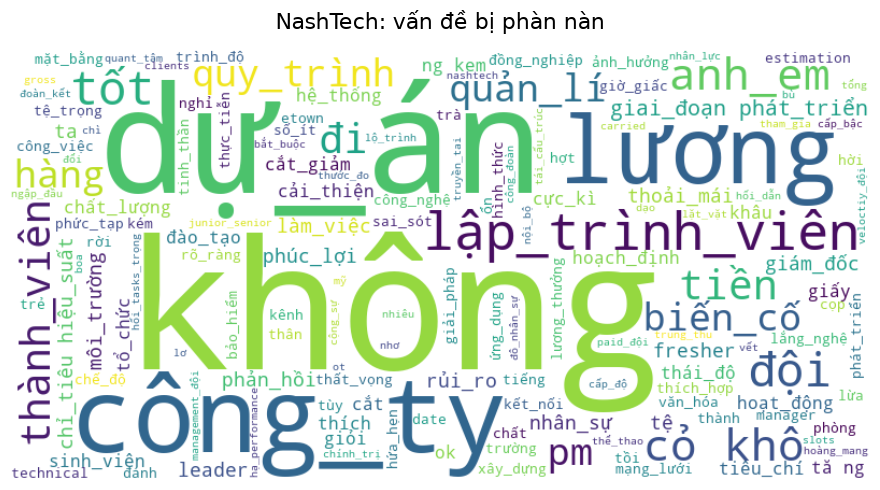

,Company Name,Reviews,Positive (%),Neutral (%),Negative (%)
0,FPT Software,2014,57.75,33.37,8.89
1,NashTech,308,69.16,26.30,4.55


In [3]:
# Chỉ chọn công ty đủ ngưỡng mẫu để tránh kết luận từ nhóm quá nhỏ.
MIN_REVIEWS = 50
CASE_STUDY_LIMIT = 2
SENTIMENT_ORDER = ["Positive", "Neutral", "Negative"]
SENTIMENT_COLORS = {"Positive": "#50e3a4", "Neutral": "#f4d35e", "Negative": "#ff6677"}

company_counts = df["Company Name"].value_counts()
eligible_companies = company_counts[company_counts >= MIN_REVIEWS]
case_study_companies = eligible_companies.head(CASE_STUDY_LIMIT).index
print(f"Có {len(eligible_companies)} công ty đạt ngưỡng {MIN_REVIEWS}+ review.")
print("Công ty được chọn làm case study:", list(case_study_companies))

case_study_rows = []
for comp in case_study_companies:
    comp_df = df[df["Company Name"] == comp].copy()
    sentiment_counts = comp_df["sentiment"].value_counts().reindex(SENTIMENT_ORDER, fill_value=0)
    sentiment_shares = sentiment_counts.div(len(comp_df)).mul(100)
    slug = re.sub(r"[^a-z0-9]+", "_", comp.lower()).strip("_")

    case_study_rows.append({
        "Company Name": comp,
        "Reviews": len(comp_df),
        **{f"{sentiment} (%)": round(sentiment_shares[sentiment], 2) for sentiment in SENTIMENT_ORDER},
    })

    fig, ax = plt.subplots(figsize=(8, 4.5))
    sns.barplot(
        x=sentiment_shares.index,
        y=sentiment_shares.values,
        hue=sentiment_shares.index,
        palette=SENTIMENT_COLORS,
        legend=False,
        ax=ax,
    )
    ax.set_title(f"Phân bố cảm xúc tại {comp} (n={len(comp_df):,})")
    ax.set_xlabel("Cảm xúc")
    ax.set_ylabel("Tỷ lệ review (%)")
    ax.set_ylim(0, max(100, sentiment_shares.max() + 10))
    for container in ax.containers:
        ax.bar_label(container, fmt="%.1f%%", padding=3)
    fig.tight_layout()
    distribution_path = f"../reports/figures/company_{slug}_sentiment_distribution.png"
    fig.savefig(distribution_path, dpi=300, bbox_inches="tight")
    print(f"Đã lưu biểu đồ tại: {distribution_path}")
    plt.show()

    for sentiment, descriptor in [("Positive", "điểm được khen ngợi"), ("Negative", "vấn đề bị phàn nàn")]:
        sentiment_text = " ".join(
            comp_df.loc[comp_df["sentiment"] == sentiment, "clean_advance_text"]
            .dropna()
            .astype(str)
        )
        if sentiment_text.strip():
            save_path = f"../reports/figures/wordcloud_{slug}_{sentiment.lower()}.png"
            generate_wordcloud(
                sentiment_text,
                title=f"{comp}: {descriptor}",
                save_path=save_path,
            )

case_study_summary = pd.DataFrame(case_study_rows)
case_study_summary
